# 3A - Indices fisicos semanais do Nino 3.4

**Pergunta especifica.** Quais variaveis fisicas descrevem o estado do sistema Nino 3.4, quais sao anomalias, quais sao valores fisicos originais e qual e a cobertura temporal real de cada serie?

**Objetivo.** Materializar a matriz semanal canonica da Fase 3, auditar sua cobertura 1981-presente e abrir a leitura longitudinal do Pacifico equatorial por Hovmoller.

**Justificativa.** A previsao antecipada do pico so pode nascer de variaveis fisicas com cobertura conhecida, eixos corretos e sem metricas auxiliares artificiais como preditores.

**Metodologia.** OISST fornece SSTA Nino 3.4 e SSTA por longitude; GLORYS12/UFS/GLO12 fornecem indices oceanicos; ERA5 fornece proxy de anomalia de estresse zonal (`tau_x_anom`). A matriz publica da Fase 3 inclui apenas SSTA, recarga/subsuperficie, SSH/tilt e vento.

**Saidas.** `phase3_indices_semanais.csv`, `phase3A_fontes_variaveis.csv`, `phase3A_cobertura_variaveis.csv`, `3A1_series_semanais.png`, `3A2_hovmoller_ssta.png`, `3A3_hovmoller_sla_taux.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
weekly = u.weekly_matrix()
weekly.to_csv(u.FEAT/'phase3_indices_semanais.csv')
sources = u.sources_note()
u.save_table(sources, 'phase3A_fontes_variaveis.csv', index=False)
print('Matriz semanal:', weekly.shape, 'periodo', weekly.index.min().date(), '->', weekly.index.max().date())
print('Variaveis publicas:', ', '.join(weekly.columns))
print(sources.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3A_fontes_variaveis.csv
Matriz semanal: (2375, 8) periodo 1981-01-04 -> 2026-07-05
Variaveis publicas: nino34_ssta, d20_m, ohc_0_300, ohc_0_700, wwv, tilt_m, ssh_m, tau_x_anom_nino34_pa
                            variavel                                                        fonte                                                                        forma         janela_real                unidade
                         nino34_ssta                                             OISST v2.1 local                               anomalia diaria 1991-2020, agregada para W-SUN            1981-09+                      C
       ssta_equatorial_lon_hovmoller                                             OISST v2.1 local                         anomalia diaria por longitude 1991-2020, faixa 2S-2N            1981-09+                      C
d20_m / ohc_* / wwv / tilt_m / ssh_m         UFS 1981-92 (ponte) -> GLORYS12 1993+ -> GLO12 cauda valor fisico/i

In [2]:
cov = pd.DataFrame({
    'inicio': weekly.apply(lambda s: s.first_valid_index()),
    'fim': weekly.apply(lambda s: s.last_valid_index()),
    'semanas_validas': weekly.notna().sum(),
    'pct_cobertura': (weekly.notna().mean()*100).round(1),
    'forma': weekly.columns.map(lambda c: sources.set_index('variavel')['forma'].to_dict().get(c, 'ver fonte especifica')),
    'unidade': weekly.columns.map(lambda c: sources.set_index('variavel')['unidade'].to_dict().get(c, '')),
}).rename_axis('variavel')
u.save_table(cov, 'phase3A_cobertura_variaveis.csv')
print(cov.to_string())


[tabela] data\processed\parquet\statistics\phase3A_cobertura_variaveis.csv
                         inicio        fim  semanas_validas  pct_cobertura                                                          forma unidade
variavel                                                                                                                                         
nino34_ssta          1981-09-06 2026-06-14             2337           98.4                 anomalia diaria 1991-2020, agregada para W-SUN       C
d20_m                1981-09-06 2026-06-14             2337           98.4                                           ver fonte especifica        
ohc_0_300            1981-09-06 2026-06-14             2337           98.4                                           ver fonte especifica        
ohc_0_700            1981-09-06 2026-06-14             2337           98.4                                           ver fonte especifica        
wwv                  1981-09-06 2026-06-14       

[figura] data\processed\figures\fase3\3A1_series_semanais.png


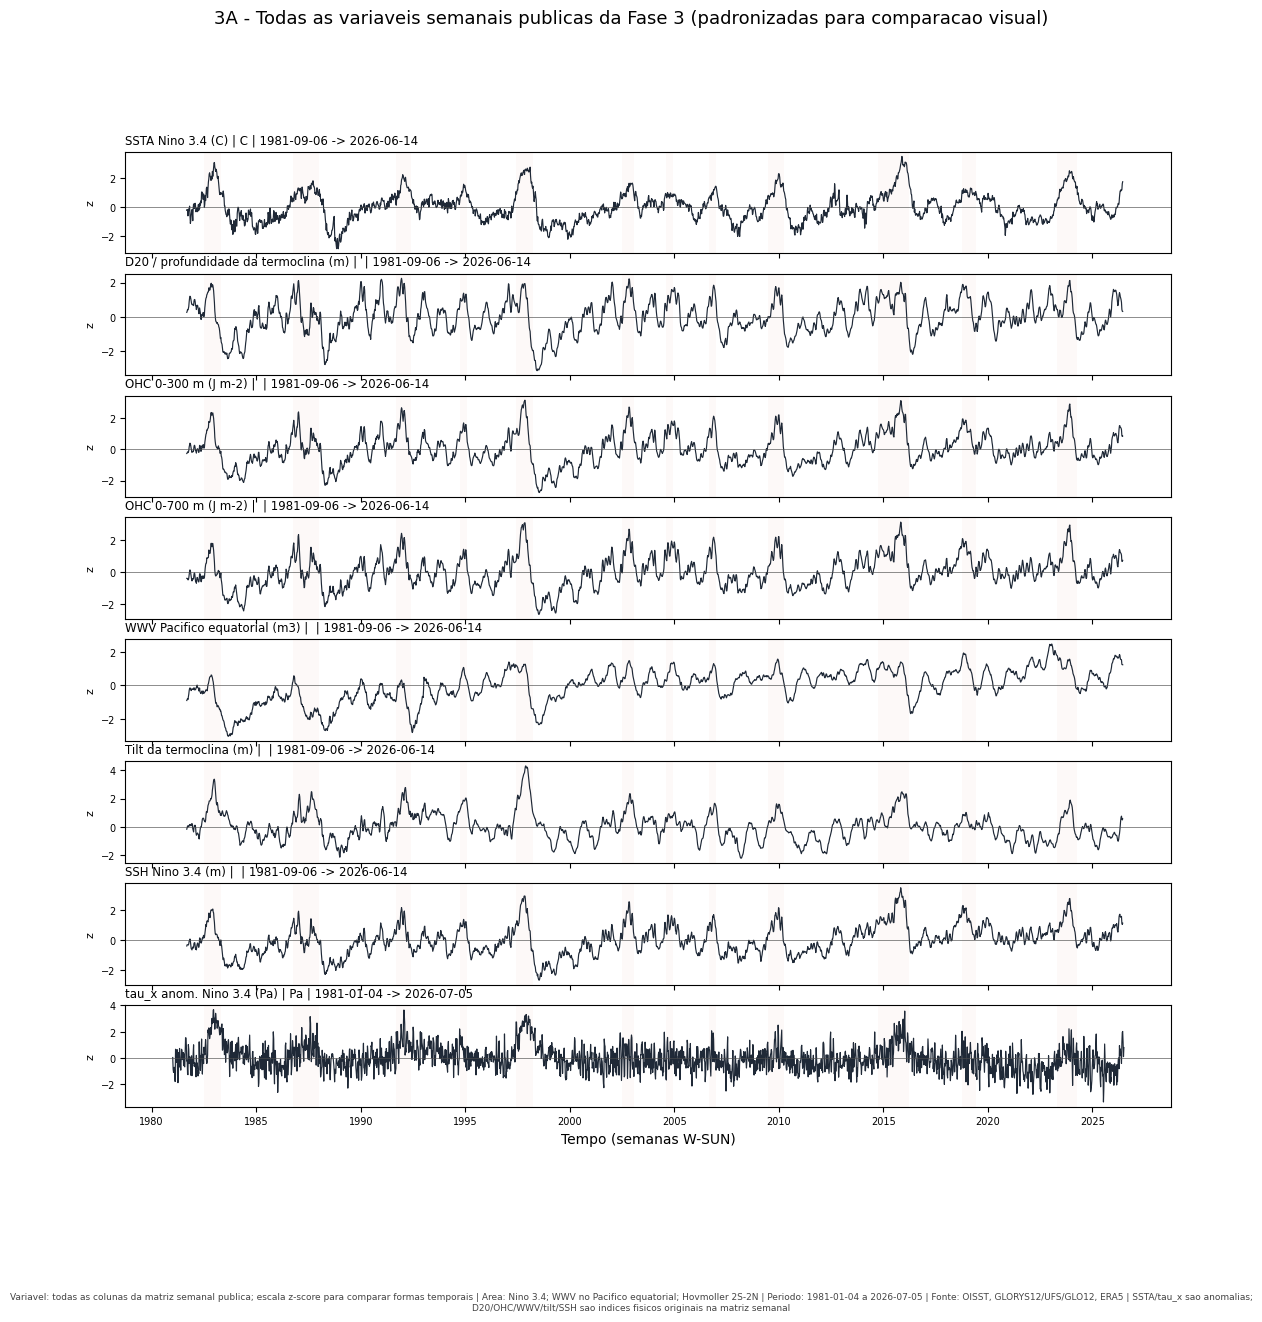

In [3]:
ev = u.load_events()
cols = list(weekly.columns)
n = len(cols)
fig, axes = plt.subplots(n, 1, figsize=(13.5, max(8, 1.55*n)), sharex=True)
if n == 1:
    axes = [axes]
for ax, col in zip(axes, cols):
    s = weekly[col].astype(float)
    std = s.std(skipna=True)
    z = (s - s.mean(skipna=True)) / std if np.isfinite(std) and std > 0 else s*0
    ax.plot(z.index, z, lw=0.85, color='#1f2937')
    u.add_event_shading(ax, ev, alpha=0.10)
    ax.axhline(0, color='0.3', lw=0.45)
    ax.set_ylabel('z', fontsize=8)
    ax.set_title(f"{u.var_label(col)} | {cov.loc[col, 'unidade']} | {cov.loc[col, 'inicio'].date()} -> {cov.loc[col, 'fim'].date()}", loc='left', fontsize=8.5)
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel('Tempo (semanas W-SUN)')
fig.suptitle('3A - Todas as variaveis semanais publicas da Fase 3 (padronizadas para comparacao visual)', y=0.995, fontsize=13)
u.stamp_caption(fig, variavel='todas as colunas da matriz semanal publica; escala z-score para comparar formas temporais', area='Nino 3.4; WWV no Pacifico equatorial; Hovmoller 2S-2N', periodo=f"{weekly.index.min().date()} a {weekly.index.max().date()}", fonte='OISST, GLORYS12/UFS/GLO12, ERA5', extra='SSTA/tau_x sao anomalias; D20/OHC/WWV/tilt/SSH sao indices fisicos originais na matriz semanal')
u.save_fig(fig, '3A1_series_semanais.png')
plt.show()

[figura] data\processed\figures\fase3\3A2_hovmoller_ssta.png


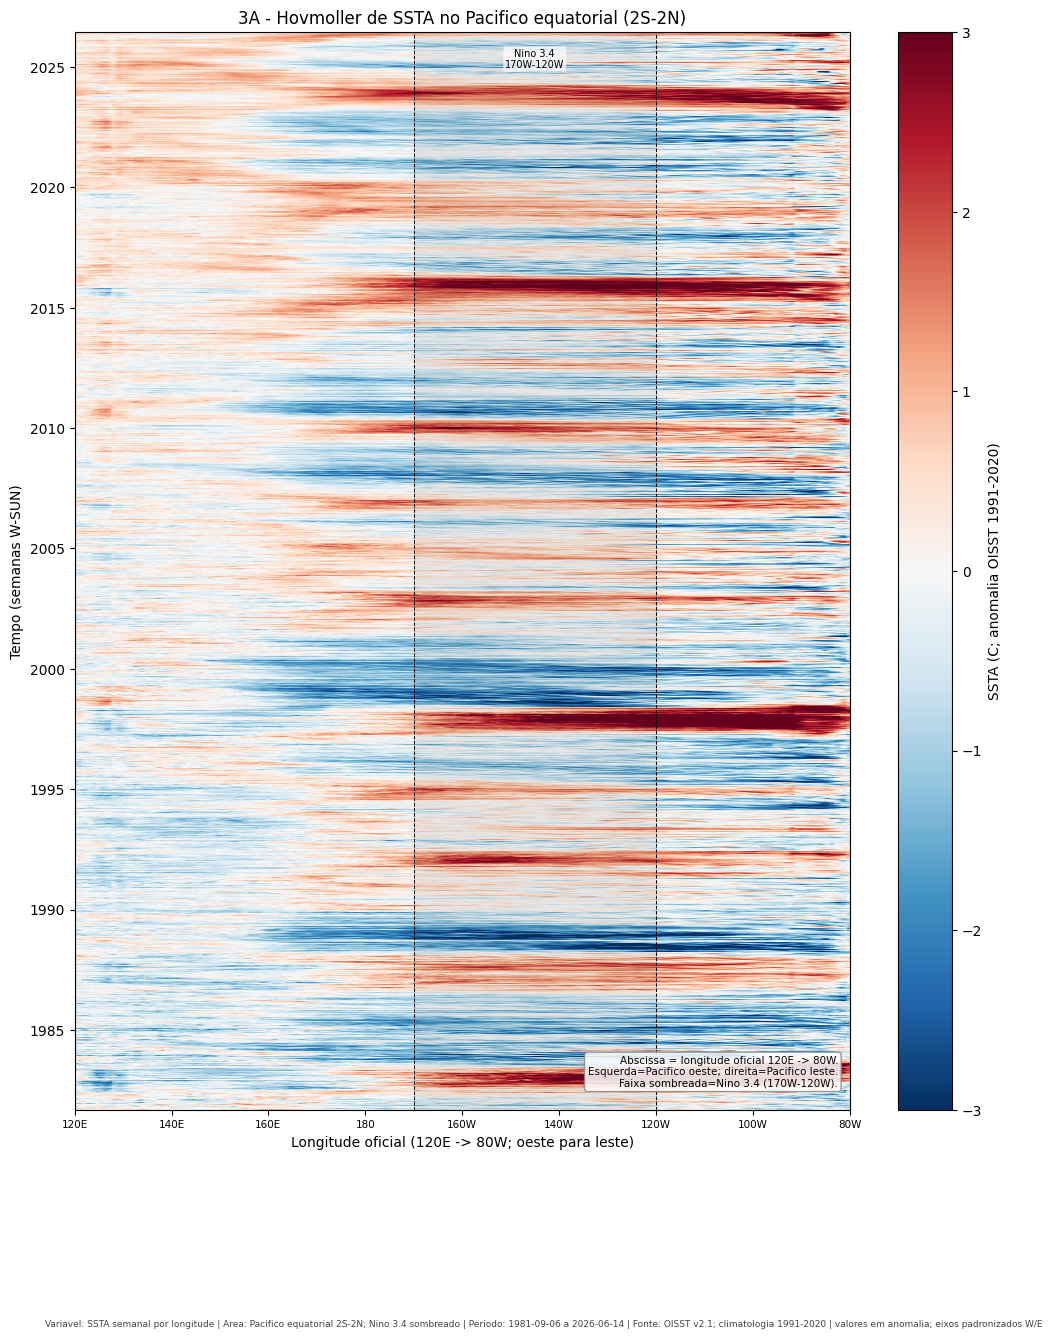

[figura] data\processed\figures\fase3\3A3_hovmoller_sla_taux.png


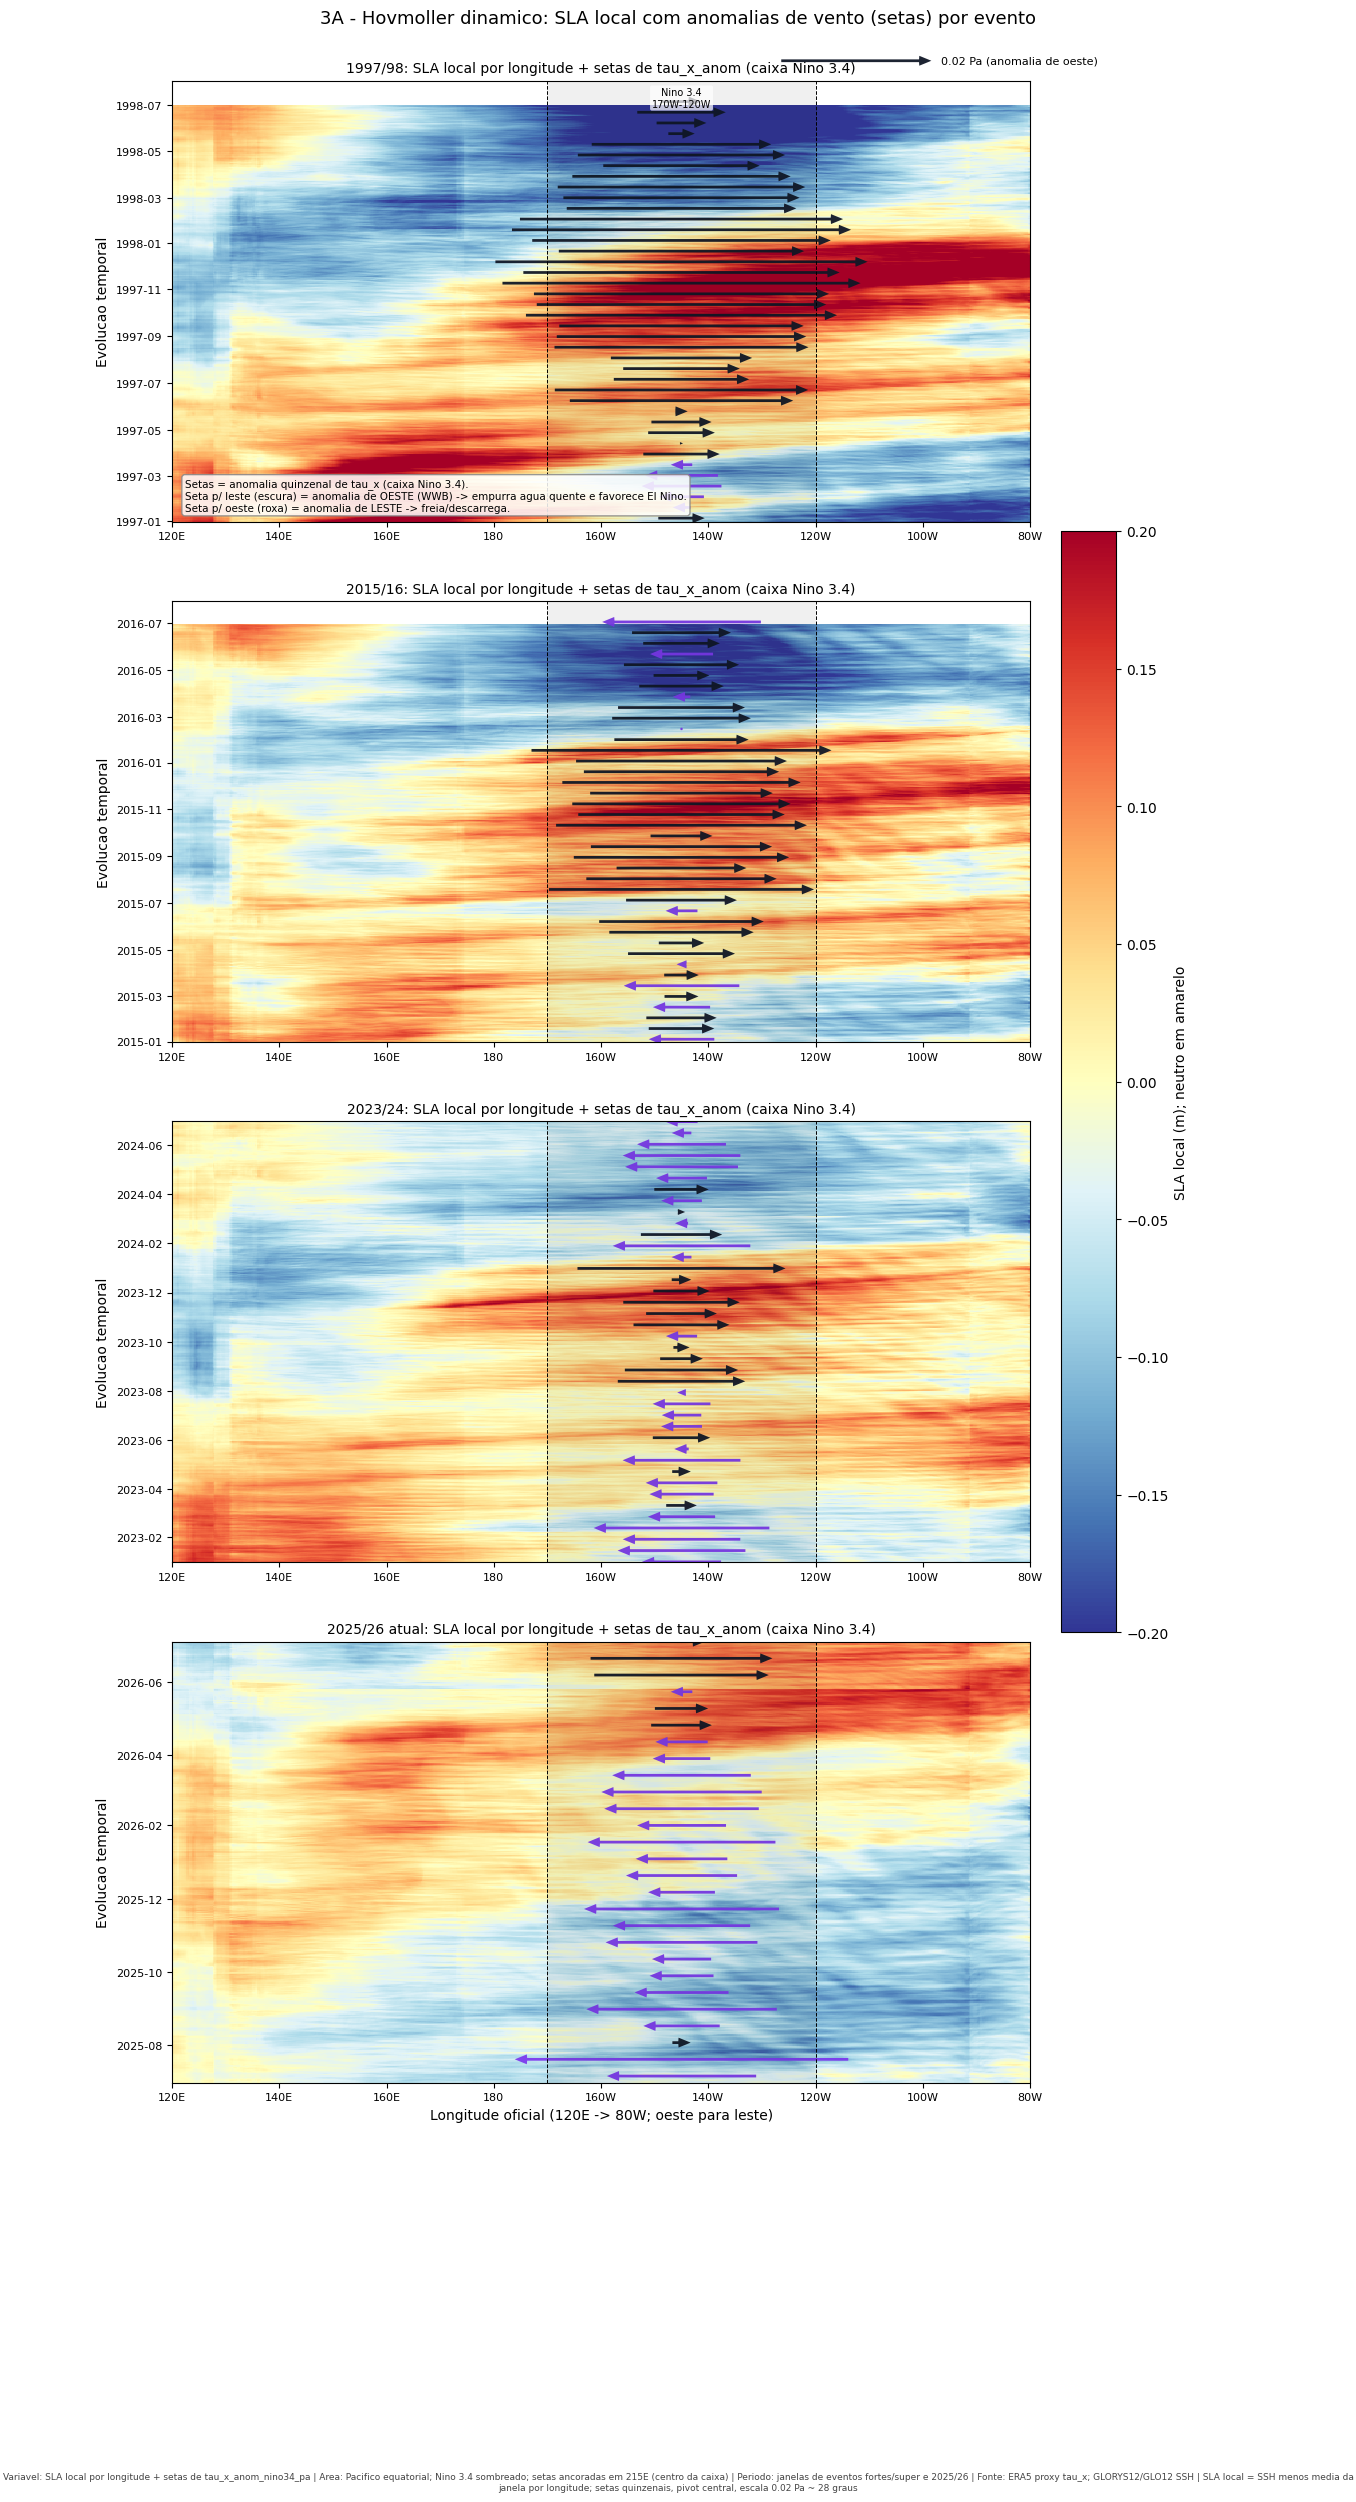

In [4]:
# Abordagem 1: Hovmoller de SSTA por longitude, usando referencias oficiais de longitude.
eq = u.load_eqband_weekly()
fig, ax = plt.subplots(figsize=(12.5, 14))
lon = eq.columns.values.astype(float)
pc = ax.pcolormesh(lon, eq.index, eq.values, cmap='RdBu_r', vmin=-3, vmax=3, shading='auto')
u.add_nino34_lon_band(ax)
u.format_lon_axis(ax)
ax.set_ylabel('Tempo (semanas W-SUN)')
ax.set_title('3A - Hovmoller de SSTA no Pacifico equatorial (2S-2N)')
fig.colorbar(pc, ax=ax, label='SSTA (C; anomalia OISST 1991-2020)')
u.add_note(ax, 'Abscissa = longitude oficial 120E -> 80W.\nEsquerda=Pacifico oeste; direita=Pacifico leste.\nFaixa sombreada=Nino 3.4 (170W-120W).', loc='lower right')
u.stamp_caption(fig, variavel='SSTA semanal por longitude', area='Pacifico equatorial 2S-2N; Nino 3.4 sombreado', periodo=f"{eq.index.min().date()} a {eq.index.max().date()}", fonte='OISST v2.1; climatologia 1991-2020', extra='valores em anomalia; eixos padronizados W/E')
u.save_fig(fig, '3A2_hovmoller_ssta.png')
plt.show()

# Abordagem 2: SLA local (SSH menos media da janela por longitude) com as anomalias
# de vento (tau_x_anom) representadas DENTRO do grafico, como setas zonais.
import matplotlib.dates as mdates
ssh = u.load_ssh_events()
tau = weekly['tau_x_anom_nino34_pa']
wins = [('1997-01-01', '1998-06-30', '1997/98'), ('2015-01-01', '2016-06-30', '2015/16'), ('2023-01-01', '2024-06-30', '2023/24'), ('2025-07-01', None, '2025/26 atual')]
TAU_REF = 0.02              # Pa da seta de referencia
TAU_SCALE = TAU_REF / 28.0  # Pa por grau de longitude: 0.02 Pa ~ 28 graus
fig, axes = plt.subplots(len(wins), 1, figsize=(13.5, 26))
fig.subplots_adjust(hspace=0.18)
last_pc, qref = None, None
for i, (ax, (t0, t1, title)) in enumerate(zip(axes, wins)):
    end = pd.to_datetime(t1) if t1 else min(ssh.index.max(), weekly.index.max())
    seg = ssh.loc[pd.to_datetime(t0):end].dropna(how='all')
    if seg.empty:
        ax.text(0.5, 0.5, 'sem SSH/SLA local', transform=ax.transAxes, ha='center', va='center')
        continue
    lon_ssh = seg.columns.values.astype(float)
    sla = seg - seg.mean(axis=0)
    last_pc = ax.pcolormesh(lon_ssh, sla.index, sla.values, cmap='RdYlBu_r', vmin=-0.20, vmax=0.20, shading='auto')
    # setas quinzenais de tau_x_anom ancoradas no centro da caixa Nino 3.4 (215E):
    # seta para a DIREITA (leste) = anomalia de OESTE (WWB; favorece Kelvin de downwelling)
    tx = tau.loc[pd.to_datetime(t0):end].resample('2W').mean().dropna()
    if not tx.empty:
        yq = mdates.date2num(tx.index.to_pydatetime())
        cols = np.where(tx.values >= 0, '#111827', '#7c3aed')
        q = ax.quiver(np.full(len(tx), 215.0), yq, tx.values, np.zeros(len(tx)),
                      color=cols, angles='xy', scale_units='x', scale=TAU_SCALE,
                      pivot='mid', width=0.0032, headwidth=3.6, headlength=4.4, alpha=0.95)
        if qref is None:
            qref = q
            ax.quiverkey(q, X=0.885, Y=1.045, U=TAU_REF, label=f'{TAU_REF} Pa (anomalia de oeste)', labelpos='E', fontproperties={'size': 8})
    u.add_nino34_lon_band(ax, label=(i == 0))
    u.format_lon_axis(ax, xlabel='Longitude oficial (120E -> 80W; oeste para leste)' if i == len(wins)-1 else '')
    ax.set_ylabel('Evolucao temporal')
    ax.set_title(f'{title}: SLA local por longitude + setas de tau_x_anom (caixa Nino 3.4)', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
u.add_note(axes[0], 'Setas = anomalia quinzenal de tau_x (caixa Nino 3.4).\nSeta p/ leste (escura) = anomalia de OESTE (WWB) -> empurra agua quente e favorece El Nino.\nSeta p/ oeste (roxa) = anomalia de LESTE -> freia/descarrega.', loc='lower left')
fig.suptitle('3A - Hovmoller dinamico: SLA local com anomalias de vento (setas) por evento', fontsize=13, y=0.9075)
if last_pc is not None:
    fig.colorbar(last_pc, ax=axes, label='SLA local (m); neutro em amarelo', shrink=0.55, pad=0.03)
u.stamp_caption(fig, variavel='SLA local por longitude + setas de tau_x_anom_nino34_pa', area='Pacifico equatorial; Nino 3.4 sombreado; setas ancoradas em 215E (centro da caixa)', periodo='janelas de eventos fortes/super e 2025/26', fonte='ERA5 proxy tau_x; GLORYS12/GLO12 SSH', extra='SLA local = SSH menos media da janela por longitude; setas quinzenais, pivot central, escala 0.02 Pa ~ 28 graus')
u.save_fig(fig, '3A3_hovmoller_sla_taux.png')
plt.show()

**Leitura do 3A.** A matriz publica da Fase 3 exibe as variaveis fisicas ativas. Nem todas sao anomalias: `nino34_ssta`, o Hovmoller de SSTA e `tau_x_anom_nino34_pa` sao anomalias; `D20/OHC/WWV/tilt/SSH` entram como indices fisicos originais/reanalise na matriz semanal. Por isso os graficos de serie usam z-score apenas para comparacao visual. O Hovmoller ficou separado em duas leituras: SSTA longitudinal e dinamica SLA/tau_x.
